# C2. micro 평균과 macro 평균

| | |
|---|---|
| **트랙** | C 평가 |
| **선수 토픽** | C1 |
| **프로젝트 앵커** | `eval.py` · `h3_macro` · 업무 구분별 hit@3 편차 |
| **작성일** | 2026-07-29 |
| **최종 검증** | 2026-07-30 |
| **상태** | 검증완료 |

## 한 줄 요약
> micro 평균은 평가셋의 문항 배분을 가중치로 쓰는 값이라, 검색기를 한 줄도 고치지 않고
> 문항을 다시 나누는 것만으로 움직인다.

## 0. 준비

필요 패키지는 `numpy`, `matplotlib` 뿐이다. C2가 다루는 것은 그룹별 점수를 하나로 합치는
방식이므로, 그룹별 점수와 문항 수만 있으면 전부 계산된다. §4는 프로젝트에 기록된 두 업무
구분의 실측치를 양 끝점으로 삼고, 그 사이를 가상 그룹으로 채워 배분의 효과만 분리한다.

In [1]:
# ── 표준 셋업 ────────────────────────────────────────────
from __future__ import annotations

import pathlib
import random

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ASSETS = pathlib.Path("../assets")
OUT = pathlib.Path("./out"); OUT.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

# 팔레트 (FUNDAMENTAL 시리즈 공용)
C_MAIN, C_SUB, C_GRAY = "#ee4c2c", "#0d9488", "#94a3b8"

_installed = {f.name for f in fm.fontManager.ttflist}
for _f in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _f in _installed:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.figsize"] = (7, 4)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

print(f"seed={SEED} · font={mpl.rcParams['font.family'][0]}")

seed=42 · font=sans-serif


## 1. 개념

### 평균을 내는 단위가 곧 질문이다

C1에서 hit@3을 정의할 때 평균의 단위는 질의였다. 질의 400개의 성패를 더해 400으로 나눈 값이
micro 평균이다. 여기에 업무 구분 같은 그룹이 있으면 다른 선택지가 생긴다. 그룹별로 먼저 평균을
내고 그 그룹 점수들을 다시 평균 내는 macro 평균이다.

> **정의**  그룹 $g$의 문항 수 $n_g$와 그룹 점수 $s_g$에 대해
> $$\text{micro} = \frac{\sum_g n_g s_g}{\sum_g n_g}, \qquad
> \text{macro} = \frac{1}{|G|}\sum_g s_g$$
> 두 값은 모든 $n_g$가 같을 때만 일치한다.

micro는 가중평균의 특수한 경우이고, 그 가중치가 **평가셋의 문항 배분**이다. macro는 가중치를
균등하게 둔 것이다. 둘 다 "가중치를 어떻게 줄 것인가"라는 하나의 질문에 대한 두 답이며,
어느 쪽도 중립이 아니다.

### 두 평균이 답하는 질문

| | micro | macro |
|---|---|---|
| 답하는 질문 | 평가셋에서 질의 하나를 뽑으면 성공할 확률은? | 업무 구분 하나를 고르면 평균 성능은? |
| 가중치 | 평가셋 문항 배분 | 그룹당 균등 |
| 소수 그룹 | 문항 수만큼만 반영 | 큰 그룹과 동등하게 반영 |
| 배분 변경 | 값이 바뀐다 | 값이 그대로다 |

> **함정**  micro가 "실제 사용 상황을 반영한다"는 설명은 평가셋의 문항 배분이 실제 트래픽
> 분포와 같을 때만 참이다. 대개 평가셋은 만들기 쉬운 문항부터 채워지므로 두 분포는 다르고,
> 그렇다면 micro는 실사용이 아니라 **평가셋을 만든 순서**를 반영하는 값이다.

### 같은 셋 안에서는 역설이 없다

모든 그룹에서 A가 B보다 좋은데 전체 평균에서는 B가 이기는 심슨의 역설은, 같은 평가셋 위에서는
일어나지 않는다. 두 시스템이 같은 $n_g$를 공유하기 때문이다. 역설이 들어오는 자리는 따로 있다.
**구성비가 다른 두 락의 micro를 비교할 때**다. 이때 점수 차이의 일부는 검색기가 아니라 배분에서
온다.

macro는 이 문제에서 자유롭다. 그룹 목록이 같기만 하면 문항 수가 달라져도 값이 비교 가능하다.
`h3_macro`를 함께 기록하는 이유가 여기 있다.

## 2. 최소 구현

두 평균은 `np.average`의 가중치 인자 하나로 갈린다. 아래 세 그룹은 점수가 낮은 그룹일수록
문항이 적은 흔한 상황이고, 이때 micro가 macro보다 높게 나온다.

In [2]:
SCORES = np.array([0.72, 0.88, 0.96])
SIZES = np.array([20, 60, 120])
NAMES = ["소수·약체", "중간", "다수·강체"]


def micro(scores: np.ndarray, sizes: np.ndarray) -> float:
    """문항 단위 평균. 그룹 크기에 비례해 가중된다."""
    return float(np.average(scores, weights=sizes))


def macro(scores: np.ndarray) -> float:
    """그룹 단위 평균. 모든 그룹에 동등 가중."""
    return float(np.mean(scores))


print(f"{'group':<12}{'score':>8}{'n':>6}{'weight':>9}")
print("-" * 35)
for name, s, n in zip(NAMES, SCORES, SIZES):
    print(f"{name:<12}{s:>8.4f}{n:>6d}{n / SIZES.sum():>9.4f}")

print(f"\nmicro = {micro(SCORES, SIZES):.4f}")
print(f"macro = {macro(SCORES):.4f}")
print(f"차이  = {micro(SCORES, SIZES) - macro(SCORES):+.4f}")

group          score     n   weight
-----------------------------------
소수·약체         0.7200    20   0.1000
중간            0.8800    60   0.3000
다수·강체         0.9600   120   0.6000

micro = 0.9120
macro = 0.8533
차이  = +0.0587


## 3. 프로젝트 앵커

`eval.py`는 전체 `hit@3`과 함께 `h3_macro`를 계산한다. 앞의 것은 질의 400개를 평평하게 센
micro 평균이고, 뒤의 것은 업무 구분마다 먼저 평균을 낸 뒤 구분끼리 다시 평균한 값이다.

> **프로젝트**  업무 구분별 hit@3에 편차가 있다. 착오송금이 0.889, 은닉이 0.984로 기록돼 있으며
> 두 구분 사이의 폭은 0.095다. 전체 hit@3은 0.945다(400문항 셋, `baseline_20260722.lock`).

이 세 숫자만으로는 `h3_macro`를 복원할 수 없다. 나머지 업무 구분의 점수와 **구분별 문항 수**를
모르기 때문이다. §4는 그래서 실측 두 값을 양 끝점으로 고정하고 중간을 가상 그룹으로 채운 뒤,
문항 배분만 바꿔가며 micro가 얼마나 움직이는지를 잰다. 절대값이 아니라 **배분 민감도**가
관심사다.

> **함정**  0.945와 0.889를 나란히 놓고 "착오송금만 약하다"고 읽는 것은 절반만 맞다. 0.945는
> 착오송금 문항을 이미 포함한 값이므로, 착오송금의 문항 수가 적을수록 0.945는 그 부진을
> 덜 반영한다. 두 숫자는 독립된 관측이 아니다.

C5에서 병합 규칙과 라벨 오류를 의심했다면, C2가 의심하는 것은 **문항이 업무 구분에 어떻게
배분됐는가**다. 라벨이 완벽해도 배분이 치우쳐 있으면 micro는 여전히 한쪽으로 기운다.

## 4. 숫자 검증

업무 구분 5개를 놓는다. 양 끝의 착오송금 0.889와 은닉 0.984는 프로젝트 기록값이고, 가운데
세 개는 그 사이를 채운 **가상 그룹**이다. 검색기 성능은 §4 전체에서 한 번도 바뀌지 않는다.
움직이는 것은 문항 배분뿐이다.

### 4-1. 배분만 바꿔 micro를 움직이기

같은 400문항을 세 가지 방식으로 나눈다. 약한 그룹에 문항을 적게 주는 배분, 균등 배분, 약한
그룹에 많이 주는 배분이다. 세 배분 모두 검색기는 동일하다.

In [3]:
GROUPS = ["착오송금", "업무B", "업무C", "업무D", "은닉"]
SCORE = np.array([0.889, 0.921, 0.945, 0.962, 0.984])   # 양 끝은 실측, 가운데 3개는 가상
PLANS = {                                                # 전부 합계 400문항 (가정한 배분)
    "약체 소수": np.array([40, 70, 120, 90, 80]),
    "균등": np.array([80, 80, 80, 80, 80]),
    "약체 다수": np.array([140, 100, 80, 40, 40]),
}

print(f"{'plan':<11}{'total':>7}{'micro':>9}{'macro':>9}{'diff':>9}")
print("-" * 45)
for name, sizes in PLANS.items():
    mi, ma = micro(SCORE, sizes), macro(SCORE)
    print(f"{name:<11}{sizes.sum():>7d}{mi:>9.4f}{ma:>9.4f}{mi - ma:>+9.4f}")

spread = max(micro(SCORE, s) for s in PLANS.values()) - \
    min(micro(SCORE, s) for s in PLANS.values())
print(f"\nmicro 변동폭 {spread:.4f} · macro 변동폭 0.0000 (검색기 불변)")

plan         total    micro    macro     diff
---------------------------------------------
약체 소수          400   0.9468   0.9402  +0.0066
균등             400   0.9402   0.9402  +0.0000
약체 다수          400   0.9250   0.9402  -0.0152

micro 변동폭 0.0218 · macro 변동폭 0.0000 (검색기 불변)


검색기를 한 줄도 고치지 않았는데 micro가 0.0218만큼 움직인다. C1 §4-3에서 인용한
`FACET_BOOST` 스윕의 +0.008보다 2.7배 큰 폭이다. **구성비가 다른 두 락의 micro를 비교하면,
그 차이의 상당 부분이 검색기가 아니라 배분에서 온 것일 수 있다.** macro는 같은 조건에서 전혀
움직이지 않는다.

### 4-2. 하나의 숫자가 지우는 것

`약체 소수` 배분에서 그룹별 점수와 두 평균선을 같이 그린다.

/tmp/ipykernel_906/2346977385.py:20: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_906/2346977385.py:20: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_906/2346977385.py:20: UserWarning: Glyph 49569 (\N{HANGUL SYLLABLE SONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_906/2346977385.py:20: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_906/2346977385.py:20: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_906/2346977385.py:20: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_906/2346977385.py:20: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


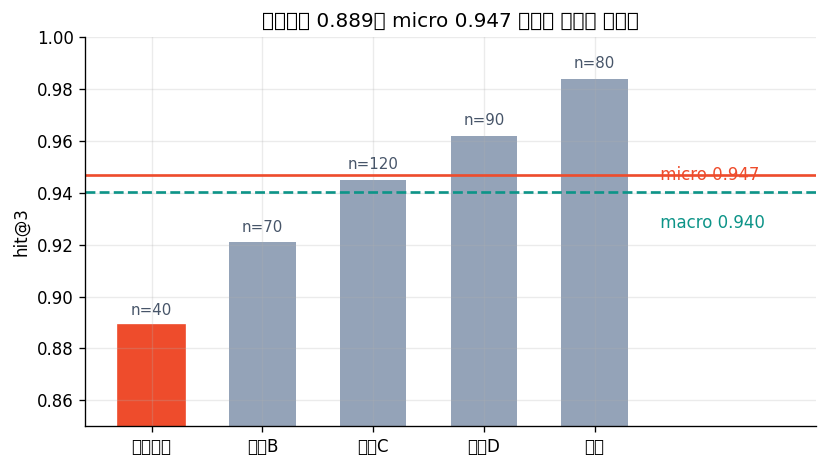

In [4]:
sizes = PLANS["약체 소수"]
mi, ma = micro(SCORE, sizes), macro(SCORE)

fig, ax = plt.subplots()
bars = ax.bar(GROUPS, SCORE, color=C_GRAY, width=0.6)
bars[0].set_color(C_MAIN)

ax.axhline(mi, color=C_MAIN, ls="-", lw=1.6)
ax.axhline(ma, color=C_SUB, ls="--", lw=1.6)
ax.text(4.55, mi, f" micro {mi:.3f}", color=C_MAIN, va="center", fontsize=10)
ax.text(4.55, ma - 0.012, f" macro {ma:.3f}", color=C_SUB, va="center", fontsize=10)

for i, (s, n) in enumerate(zip(SCORE, sizes)):
    ax.text(i, s + 0.004, f"n={n}", ha="center", color="#475569", fontsize=9)

ax.set_ylabel("hit@3")
ax.set_ylim(0.85, 1.0)
ax.set_xlim(-0.6, 6.0)
ax.set_title("착오송금 0.889는 micro 0.947 안에서 보이지 않는다")
plt.tight_layout()
plt.show()

착오송금 막대만 두 평균선에서 크게 떨어져 있는데, 문항이 40개뿐이라 micro에는 10%의 무게로만
들어간다. 리포트에 micro 하나만 적히면 이 그룹의 부진은 반올림 안쪽으로 사라진다. 업무 구분이
곧 사용자 집단이라면, 지워지는 것은 숫자가 아니라 **그 업무로 들어오는 사용자 전체**다.

### 4-3. 지표가 개선 우선순위를 정한다

같은 크기의 개선을 어느 그룹에 넣느냐에 따라 두 평균이 다르게 반응한다. `약체 소수` 배분에서
착오송금(40문항)과 업무C(120문항)에 각각 +0.05를 주고 비교한다.

In [5]:
base_micro, base_macro = micro(SCORE, sizes), macro(SCORE)
GAIN = 0.05

print(f"{'improved':<10}{'n':>6}{'d micro':>10}{'d macro':>10}")
print("-" * 36)
for idx in (0, 2):
    lifted = SCORE.copy()
    lifted[idx] += GAIN
    print(f"{GROUPS[idx]:<10}{sizes[idx]:>6d}"
          f"{micro(lifted, sizes) - base_micro:>+10.4f}"
          f"{macro(lifted) - base_macro:>+10.4f}")

print(f"\nmicro 기준 효율 차이 {sizes[2] / sizes[0]:.1f}배 · macro 기준 동일")

improved       n   d micro   d macro
------------------------------------
착오송금          40   +0.0050   +0.0100
업무C          120   +0.0150   +0.0100

micro 기준 효율 차이 3.0배 · macro 기준 동일


micro만 보고 최적화하면 업무C를 고치는 쪽이 3배 효율적이다. 그런데 업무C는 이미 0.945로
평균 수준이고, 손봐야 할 곳은 0.889인 착오송금이다. **micro를 1차 지표로 두면 이미 잘하는
그룹을 더 잘하게 만드는 데 자원을 쓰라는 신호가 나간다.** macro는 어느 그룹이든 같은 크기로
반응하므로 이 왜곡이 없다.

### 4-4. 그럼 무엇을 보아야 하는가

micro와 macro는 가중치의 두 극단일 뿐이다. 실제로 알고 싶은 값은 대개 **실 트래픽 분포로
가중한 평균**이다. 평가셋 배분과 트래픽 분포가 다를 때 세 값이 얼마나 벌어지는지 본다.
트래픽 가중치는 착오송금 문의가 실제로 많다는 가정을 넣은 예시값이다.

In [6]:
W_TRAFFIC = np.array([0.35, 0.20, 0.20, 0.15, 0.10])   # 가정한 실 트래픽 구성비
w_eval = sizes / sizes.sum()

print(f"{'group':<10}{'score':>8}{'w_eval':>9}{'w_traffic':>11}")
print("-" * 38)
for g, s, we, wt in zip(GROUPS, SCORE, w_eval, W_TRAFFIC):
    print(f"{g:<10}{s:>8.4f}{we:>9.4f}{wt:>11.4f}")

traffic = float(np.average(SCORE, weights=W_TRAFFIC))
print(f"\n{'micro (평가셋 가중)':<22}{base_micro:>9.4f}")
print(f"{'macro (균등 가중)':<22}{base_macro:>9.4f}")
print(f"{'트래픽 가중':<22}{traffic:>9.4f}")
print(f"\nmicro는 체감 성능을 {base_micro - traffic:+.4f} 과대평가한다.")

group        score   w_eval  w_traffic
--------------------------------------
착오송금        0.8890   0.1000     0.3500
업무B         0.9210   0.1750     0.2000
업무C         0.9450   0.3000     0.2000
업무D         0.9620   0.2250     0.1500
은닉          0.9840   0.2000     0.1000

micro (평가셋 가중)           0.9468
macro (균등 가중)            0.9402
트래픽 가중                   0.9271

micro는 체감 성능을 +0.0198 과대평가한다.


셋 중 트래픽 가중값이 가장 낮다. 약한 그룹이 평가셋에서는 소수인데 실제 문의에서는 다수이기
때문이다. micro는 이 상황에서 체감 성능을 0.02 과대평가한다. macro가 그보다 나은 이유는
균등 가중이 옳아서가 아니라, **평가셋 배분이라는 임의의 가중치를 쓰지 않기 때문**이다.

정확히는 셋 다 근사값이다. 트래픽 분포를 실제로 집계해 가중치로 쓰는 것이 제일 나은 답이고,
그게 없을 때 macro가 덜 위험한 대역이다.

§4를 한 줄로 줄이면 이렇다. **평균은 데이터를 요약하는 중립적 연산이 아니라, 누구의 목소리를
얼마나 크게 들을지 정하는 결정이다.** micro는 평가셋을 만든 사람의 문항 배분에 그 결정을
위임하고, macro는 그룹 목록에 위임한다. 어느 쪽도 저절로 옳지 않으므로 둘을 같이 보고,
벌어지면 그 이유를 배분에서 찾아야 한다.

0단계 네 노트북을 묶으면 판단 기준의 뼈대가 나온다. 지표가 무엇을 세는지(C1), 평가셋이 어떤
질문을 던지는지(C4), gold를 누가 어떻게 정했는지(C5), 그리고 그 결과를 어떤 가중치로 합쳤는지
(C2). 이후 A·B·D 트랙에서 보게 될 모든 수치는 이 네 층을 통과한 값이다.

## 5. 남은 질문

- 업무 구분별 문항 수를 확인해야 한다. §4-1이 보여준 대로 배분을 모르면 `hit@3`과 `h3_macro`의
  차이를 해석할 수 없고, 착오송금 0.889가 전체 0.945에 얼마나 반영됐는지도 알 수 없다.
- `baseline_20260722.lock`과 그 이전 락의 업무 구분별 배분이 같은가? 다르다면 두 락의 micro
  비교는 §4-1의 변동폭만큼 오염돼 있다.
- 400문항 셋과 300문항 셋의 구성비가 같은지 확인이 필요하다. 셋을 줄이면서 배분이 바뀌었다면
  두 셋의 micro는 서로 다른 가중치로 계산된 값이다(C3와 함께 볼 문제).
- 실 트래픽의 업무 구분별 비중을 집계할 수 있는가? §4-4의 가중치는 가정값이며, 로그가 있다면
  micro·macro 대신 트래픽 가중 지표를 1차로 둘 수 있다.
- 착오송금이 낮은 원인이 검색 난이도인지 문항 품질인지 아직 구분되지 않았다. C5 §4-1 기준으로
  특정 업무 구분에 라벨 오류가 몰려 있으면 그 그룹 점수만 눌린다. 교정한 gt 8건이 어느 구분에
  속했는지 확인하면 바로 갈린다.
- 업무 구분이 5개보다 세분화되면 macro의 분산이 커진다. 문항이 몇 개 안 되는 구분이 macro에서
  큰 그룹과 동등한 무게를 갖는 것이 타당한지는 구분 정의에 달렸고, 아직 검토하지 않았다.

## 참고

- Manning, Raghavan & Schütze (2008), *Introduction to Information Retrieval* 13.6절 —
  micro/macro 평균 정의
- Sokolova & Lapalme (2009), *A Systematic Analysis of Performance Measures for
  Classification Tasks*
- Buolamwini & Gebru (2018), *Gender Shades* — 전체 평균이 소수 그룹의 부진을 가린 사례
- Sagawa et al. (2020), *Distributionally Robust Neural Networks for Group Shifts* —
  최악 그룹 성능을 1차 지표로 두는 접근
- 프로젝트: `eval.py`, `h3_macro`, `baseline_20260722.lock`